In [228]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 200)

In [95]:
healthcare_df = pd.read_excel('../data/raw/Healthcare Dataset.xlsx')
healthcare_df.head()

,Location,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Date and Time,Age,Gender,Marital Status,"How many children do you have, if any?",Employment Status,Monthly Household Income,Have you ever had health insurance?,"If yes, which insurance cover?",When was the last time you visited a hospital for medical treatment? (In Months),Did you have health insurance during your last hospital visit?,Have you ever had a routine check-up with a doctor or healthcare provider?,"If you answered yes to the previous question, what time period (in years) do you stay before having your routine check-up?","Have you ever had a cancer screening (e.g. mammogram, colonoscopy, etc.)?","If you answered yes to the previous question, what time period (in years) do you stay before having your Cancer screening?",Your Picture,Your Picture_URL,_id,_uuid,_submission_time,_validation_status,_notes,_status,_submitted_by,__version__,_tags,_index
0,-0.2742007 36.058336 1882.2000732421875 20.0,-0.274201,36.058336,1882.200073,20.0,NaT,41-50,Female,Married,2.0,Self-employed,20001-30000,Yes,Nhif,53.0,No,Yes,2,No,2,NaN,NaN,230162389,aa30304f-84f2-4c1b-b30a-371241f2ff17,2023-04-05 08:44:06,NaN,NaN,submitted_via_web,NaN,vJ8gEKnN2pccxThc5jnkz4,NaN,1
1,-0.7158125 37.1475058 1361.9000244140625 20.0,-0.715812,37.147506,1361.900024,20.0,2023-05-15 13:38:00,18-30,Male,Single,0.0,Unemployed,Less than 10000,No,NaN,8.0,No,Yes,1,No,NaN,NaN,NaN,238299334,63c461e3-b3ef-47cf-9632-0c912a639f46,2023-05-15 10:44:01,NaN,NaN,submitted_via_web,safra_data,vMrCPR7NLZZJrf4PTsQ8uH,NaN,2
2,-0.7158157 37.1475082 1361.9000244140625 20.0,-0.715816,37.147508,1361.900024,20.0,2023-05-15 13:49:00,41-50,Female,Married,5.0,Self-employed,20001-30000,No,Nhif,6.0,Yes,No,NaN,Yes,4+,NaN,NaN,238301092,4209a55d-a983-433f-8ce0-bce6cd28d713,2023-05-15 10:51:08,NaN,NaN,submitted_via_web,safra_data,vMrCPR7NLZZJrf4PTsQ8uH,NaN,3
3,-0.7157082 37.14749 1361.9000244140625 20.0,-0.715708,37.147490,1361.900024,20.0,2023-05-15 14:19:00,18-30,Male,Single,NaN,Self-employed,10001-20000,Yes,Nhif,16.0,Yes,No,NaN,No,NaN,NaN,NaN,238311207,2eba9b13-1706-4faf-b7a7-e45e9dcf48ab,2023-05-15 11:22:19,NaN,NaN,submitted_via_web,safra_data,vMrCPR7NLZZJrf4PTsQ8uH,NaN,4
4,-0.7157337 37.1474799 1361.9000244140625 20.0,-0.715734,37.147480,1361.900024,20.0,2023-05-15 14:30:00,41-50,Male,Married,7.0,Self-employed,20001-30000,Yes,Nhif,13.0,Yes,No,NaN,Yes,4+,NaN,NaN,238314477,1f49cb82-75ff-4391-b69b-973a6ce698ee,2023-05-15 11:33:21,NaN,NaN,submitted_via_web,safra_data,vMrCPR7NLZZJrf4PTsQ8uH,NaN,5


### Perfoming Data Cleaning

In [96]:
healthcare_df.isnull().sum()

Location                                                                                                                       353
_Location_latitude                                                                                                             353
_Location_longitude                                                                                                            353
_Location_altitude                                                                                                             353
_Location_precision                                                                                                            353
Date and Time                                                                                                                  148
Age                                                                                                                             18
Gender                                                                             

In [97]:
healthcare_df.columns

Index(['Location', '_Location_latitude', '_Location_longitude',
       '_Location_altitude', '_Location_precision', 'Date and Time', 'Age',
       'Gender', 'Marital Status', 'How many children do you have, if any?',
       'Employment Status', 'Monthly Household Income',
       'Have you ever had health insurance?', 'If yes, which insurance cover?',
       'When was the last time you visited a hospital for medical treatment? (In Months)',
       'Did you have health insurance during your last hospital visit?',
       'Have you ever had a routine check-up with a doctor or healthcare provider?',
       'If you answered yes to the previous question, what time period (in years) do you stay before having your routine check-up?',
       'Have you ever had a cancer screening (e.g. mammogram, colonoscopy, etc.)?',
       'If you answered yes to the previous question, what time period (in years) do you stay before having your Cancer screening?',
       'Your Picture', 'Your Picture_URL', '_id'

In [98]:
healthcare_df = healthcare_df.drop(columns=['Your Picture', 'Your Picture_URL', '_id', '_uuid', '_submission_time',
       '_validation_status', '_notes', '_status', '_submitted_by',
       '__version__', '_tags', '_index'])
healthcare_df.head()

,Location,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Date and Time,Age,Gender,Marital Status,"How many children do you have, if any?",Employment Status,Monthly Household Income,Have you ever had health insurance?,"If yes, which insurance cover?",When was the last time you visited a hospital for medical treatment? (In Months),Did you have health insurance during your last hospital visit?,Have you ever had a routine check-up with a doctor or healthcare provider?,"If you answered yes to the previous question, what time period (in years) do you stay before having your routine check-up?","Have you ever had a cancer screening (e.g. mammogram, colonoscopy, etc.)?","If you answered yes to the previous question, what time period (in years) do you stay before having your Cancer screening?"
0,-0.2742007 36.058336 1882.2000732421875 20.0,-0.274201,36.058336,1882.200073,20.0,NaT,41-50,Female,Married,2.0,Self-employed,20001-30000,Yes,Nhif,53.0,No,Yes,2,No,2
1,-0.7158125 37.1475058 1361.9000244140625 20.0,-0.715812,37.147506,1361.900024,20.0,2023-05-15 13:38:00,18-30,Male,Single,0.0,Unemployed,Less than 10000,No,NaN,8.0,No,Yes,1,No,NaN
2,-0.7158157 37.1475082 1361.9000244140625 20.0,-0.715816,37.147508,1361.900024,20.0,2023-05-15 13:49:00,41-50,Female,Married,5.0,Self-employed,20001-30000,No,Nhif,6.0,Yes,No,NaN,Yes,4+
3,-0.7157082 37.14749 1361.9000244140625 20.0,-0.715708,37.147490,1361.900024,20.0,2023-05-15 14:19:00,18-30,Male,Single,NaN,Self-employed,10001-20000,Yes,Nhif,16.0,Yes,No,NaN,No,NaN
4,-0.7157337 37.1474799 1361.9000244140625 20.0,-0.715734,37.147480,1361.900024,20.0,2023-05-15 14:30:00,41-50,Male,Married,7.0,Self-employed,20001-30000,Yes,Nhif,13.0,Yes,No,NaN,Yes,4+


In [99]:
healthcare_df.rename(columns={'How many children do you have, if any?': 'Children',
                      'Have you ever had health insurance?': 'Health_Insurance',
                     'If yes, which insurance cover?': 'Insurance_cover',
                     'When was the last time you visited a hospital for medical treatment? (In Months)': 'Last_Hosptal_visit',
                     'Did you have health insurance during your last hospital visit?': 'Last_Hosptal_visit_insurance',
                     'Have you ever had a routine check-up with a doctor or healthcare provider?': 'Check-up',
                     'If you answered yes to the previous question, what time period (in years) do you stay before having your routine check-up?': 'Years_to_Checkup',
                     'Have you ever had a cancer screening (e.g. mammogram, colonoscopy, etc.)?': 'Cancer_Screening',
                     'If you answered yes to the previous question, what time period (in years) do you stay before having your Cancer screening?': 'Years_to_Screening'}, inplace=True)

In [100]:
healthcare_df.head()

,Location,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Date and Time,Age,Gender,Marital Status,Children,Employment Status,Monthly Household Income,Health_Insurance,Insurance_cover,Last_Hosptal_visit,Last_Hosptal_visit_insurance,Check-up,Years_to_Checkup,Cancer_Screening,Years_to_Screening
0,-0.2742007 36.058336 1882.2000732421875 20.0,-0.274201,36.058336,1882.200073,20.0,NaT,41-50,Female,Married,2.0,Self-employed,20001-30000,Yes,Nhif,53.0,No,Yes,2,No,2
1,-0.7158125 37.1475058 1361.9000244140625 20.0,-0.715812,37.147506,1361.900024,20.0,2023-05-15 13:38:00,18-30,Male,Single,0.0,Unemployed,Less than 10000,No,NaN,8.0,No,Yes,1,No,NaN
2,-0.7158157 37.1475082 1361.9000244140625 20.0,-0.715816,37.147508,1361.900024,20.0,2023-05-15 13:49:00,41-50,Female,Married,5.0,Self-employed,20001-30000,No,Nhif,6.0,Yes,No,NaN,Yes,4+
3,-0.7157082 37.14749 1361.9000244140625 20.0,-0.715708,37.147490,1361.900024,20.0,2023-05-15 14:19:00,18-30,Male,Single,NaN,Self-employed,10001-20000,Yes,Nhif,16.0,Yes,No,NaN,No,NaN
4,-0.7157337 37.1474799 1361.9000244140625 20.0,-0.715734,37.147480,1361.900024,20.0,2023-05-15 14:30:00,41-50,Male,Married,7.0,Self-employed,20001-30000,Yes,Nhif,13.0,Yes,No,NaN,Yes,4+


In [101]:
healthcare_df.drop(columns='Date and Time', inplace=True)

In [102]:
healthcare_df.head()

,Location,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Age,Gender,Marital Status,Children,Employment Status,Monthly Household Income,Health_Insurance,Insurance_cover,Last_Hosptal_visit,Last_Hosptal_visit_insurance,Check-up,Years_to_Checkup,Cancer_Screening,Years_to_Screening
0,-0.2742007 36.058336 1882.2000732421875 20.0,-0.274201,36.058336,1882.200073,20.0,41-50,Female,Married,2.0,Self-employed,20001-30000,Yes,Nhif,53.0,No,Yes,2,No,2
1,-0.7158125 37.1475058 1361.9000244140625 20.0,-0.715812,37.147506,1361.900024,20.0,18-30,Male,Single,0.0,Unemployed,Less than 10000,No,NaN,8.0,No,Yes,1,No,NaN
2,-0.7158157 37.1475082 1361.9000244140625 20.0,-0.715816,37.147508,1361.900024,20.0,41-50,Female,Married,5.0,Self-employed,20001-30000,No,Nhif,6.0,Yes,No,NaN,Yes,4+
3,-0.7157082 37.14749 1361.9000244140625 20.0,-0.715708,37.147490,1361.900024,20.0,18-30,Male,Single,NaN,Self-employed,10001-20000,Yes,Nhif,16.0,Yes,No,NaN,No,NaN
4,-0.7157337 37.1474799 1361.9000244140625 20.0,-0.715734,37.147480,1361.900024,20.0,41-50,Male,Married,7.0,Self-employed,20001-30000,Yes,Nhif,13.0,Yes,No,NaN,Yes,4+


In [103]:
healthcare_df.describe()

,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Children,Last_Hosptal_visit
count,5805.000000,5805.000000,5805.000000,5805.000000,5533.000000,6000.000000
mean,-0.737841,36.715208,1536.439555,71.217272,147.165371,6.651875
std,0.870519,0.866878,494.157138,388.100302,10757.084650,37.295530
min,-4.051936,34.092111,-201.295000,0.000000,0.000000,0.000000
25%,-1.259315,36.379644,1348.900024,4.100000,1.000000,2.000000
50%,-0.726425,36.866007,1592.900024,4.820000,2.000000,4.000000
75%,-0.378057,37.146309,1857.600000,7.196000,3.000000,8.000000
max,1.842157,39.692109,2988.477000,4900.000000,800159.000000,2021.000000


In [104]:
healthcare_df.isnull().sum()

Location                         353
_Location_latitude               353
_Location_longitude              353
_Location_altitude               353
_Location_precision              353
Age                               18
Gender                            17
Marital Status                    18
Children                         625
Employment Status                 24
Monthly Household Income         259
Health_Insurance                  19
Insurance_cover                 2540
Last_Hosptal_visit               158
Last_Hosptal_visit_insurance      56
Check-up                          23
Years_to_Checkup                4382
Cancer_Screening                  31
Years_to_Screening              4593
dtype: int64

In [105]:
healthcare_df.dropna(subset=['Location','_Location_latitude','_Location_longitude','_Location_altitude','_Location_precision','Age','Gender','Marital Status','Employment Status','Monthly Household Income','Last_Hosptal_visit','Last_Hosptal_visit_insurance','Check-up','Cancer_Screening','Health_Insurance'], inplace=True)

In [106]:
healthcare_df.head(10)

,Location,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Age,Gender,Marital Status,Children,Employment Status,Monthly Household Income,Health_Insurance,Insurance_cover,Last_Hosptal_visit,Last_Hosptal_visit_insurance,Check-up,Years_to_Checkup,Cancer_Screening,Years_to_Screening
0,-0.2742007 36.058336 1882.2000732421875 20.0,-0.274201,36.058336,1882.200073,20.000,41-50,Female,Married,2.0,Self-employed,20001-30000,Yes,Nhif,53.0,No,Yes,2,No,2
1,-0.7158125 37.1475058 1361.9000244140625 20.0,-0.715812,37.147506,1361.900024,20.000,18-30,Male,Single,0.0,Unemployed,Less than 10000,No,NaN,8.0,No,Yes,1,No,NaN
2,-0.7158157 37.1475082 1361.9000244140625 20.0,-0.715816,37.147508,1361.900024,20.000,41-50,Female,Married,5.0,Self-employed,20001-30000,No,Nhif,6.0,Yes,No,NaN,Yes,4+
3,-0.7157082 37.14749 1361.9000244140625 20.0,-0.715708,37.147490,1361.900024,20.000,18-30,Male,Single,NaN,Self-employed,10001-20000,Yes,Nhif,16.0,Yes,No,NaN,No,NaN
4,-0.7157337 37.1474799 1361.9000244140625 20.0,-0.715734,37.147480,1361.900024,20.000,41-50,Male,Married,7.0,Self-employed,20001-30000,Yes,Nhif,13.0,Yes,No,NaN,Yes,4+
5,-0.7158041 37.1475364 1361.9000244140625 26.107,-0.715804,37.147536,1361.900024,26.107,18-30,Female,Single,NaN,Unemployed,10001-20000,Yes,Nhif,2.0,Yes,No,NaN,No,NaN
6,-0.715893 37.1473531 1361.5999755859375 32.483,-0.715893,37.147353,1361.599976,32.483,31-40,Female,Married,2.0,Self-employed,10001-20000,Yes,Nhif,4.0,Yes,No,NaN,No,NaN
7,-0.7159403 37.1463094 1362.2000732421875 56.1,-0.715940,37.146309,1362.200073,56.100,18-30,Male,Single,NaN,Self-employed,Less than 10000,No,NaN,24.0,No,No,NaN,No,NaN
8,-0.7159117 37.1470772 1362.2000732421875 33.011,-0.715912,37.147077,1362.200073,33.011,31-40,Female,Married,3.0,Employed,20001-30000,Yes,Nhif,5.0,Yes,No,NaN,No,NaN
9,-0.7158706 37.1466718 1362.2000732421875 52.4,-0.715871,37.146672,1362.200073,52.400,31-40,Female,Married,2.0,Employed,10001-20000,Yes,Nhif,6.0,Yes,No,NaN,No,NaN


In [107]:
healthcare_df.drop(columns='Location', inplace=True)

In [108]:
healthcare_df.tail(10)

,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Age,Gender,Marital Status,Children,Employment Status,Monthly Household Income,Health_Insurance,Insurance_cover,Last_Hosptal_visit,Last_Hosptal_visit_insurance,Check-up,Years_to_Checkup,Cancer_Screening,Years_to_Screening
6148,-0.988309,36.858818,1807.100000,3.300,51-60,Male,Married,4.0,Self-employed,20001-30000,No,NaN,52.0,No,No,NaN,No,NaN
6149,-0.997367,36.871807,1807.100000,4.900,51-60,Female,Married,3.0,Self-employed,10001-20000,No,NaN,36.0,No,Yes,4+,No,NaN
6150,-0.997789,36.872784,1756.200000,4.925,41-50,Female,Married,4.0,Unemployed,Less than 10000,No,NaN,23.0,No,Yes,4+,No,NaN
6151,-0.987481,36.854175,1756.200000,4.900,60+,Female,Married,4.0,Self-employed,50001+,Yes,NHIF,13.0,Yes,Yes,4+,No,NaN
6152,-1.268939,36.892414,1617.800000,4.950,31-40,Male,Married,2.0,Self-employed,20001-30000,Yes,NHIF,6.0,Yes,Yes,3,No,NaN
6153,-1.269310,36.891695,1618.000000,4.816,18-30,Female,Single,NaN,Self-employed,Less than 10000,Yes,ICEA LION GROUP,3.0,Yes,Yes,2,No,NaN
6154,-1.270522,36.892388,1594.900024,5.000,41-50,Male,Married,6.0,Self-employed,40001-50000,Yes,APA INSURANCE,3.0,Yes,Yes,1,Yes,1
6155,-1.271808,36.893101,1594.900024,4.840,31-40,Female,Married,3.0,Employed,10001-20000,Yes,NHIF,6.0,Yes,No,NaN,Yes,2
6156,-1.273072,36.893833,1594.900024,4.840,31-40,Male,Divorced,2.0,Self-employed,Less than 10000,Yes,CIC INSURANCE GROUP,5.0,Yes,Yes,2,Yes,1
6157,-1.273937,36.894248,1594.900024,4.616,31-40,Female,Married,1.0,Unemployed,Less than 10000,Yes,NHIF,3.0,Yes,Yes,1,Yes,1


In [109]:
healthcare_df.isnull().sum()

_Location_latitude                 0
_Location_longitude                0
_Location_altitude                 0
_Location_precision                0
Age                                0
Gender                             0
Marital Status                     0
Children                         415
Employment Status                  0
Monthly Household Income           0
Health_Insurance                   0
Insurance_cover                 2140
Last_Hosptal_visit                 0
Last_Hosptal_visit_insurance       0
Check-up                           0
Years_to_Checkup                3761
Cancer_Screening                   0
Years_to_Screening              3966
dtype: int64

In [110]:
healthcare_df.dtypes

_Location_latitude              float64
_Location_longitude             float64
_Location_altitude              float64
_Location_precision             float64
Age                              object
Gender                           object
Marital Status                   object
Children                        float64
Employment Status                object
Monthly Household Income         object
Health_Insurance                 object
Insurance_cover                  object
Last_Hosptal_visit              float64
Last_Hosptal_visit_insurance     object
Check-up                         object
Years_to_Checkup                 object
Cancer_Screening                 object
Years_to_Screening               object
dtype: object

In [111]:
for column in healthcare_df.columns :
    print(f'Value Counts of column {column}')
    print(healthcare_df[column].value_counts())
    print("\n")


Value Counts of column _Location_latitude
_Location_latitude
 0.159677    13
-1.095722    13
 0.177447    12
 0.107768    10
 0.107196    10
             ..
-0.464740     1
-0.464838     1
-0.462455     1
-1.483411     1
-1.273937     1
Name: count, Length: 5114, dtype: int64


Value Counts of column _Location_longitude
_Location_longitude
35.877235    13
37.744335    13
37.763959    12
37.605106    10
36.217820    10
             ..
36.610167     1
36.609941     1
37.559070     1
37.558675     1
36.894248     1
Name: count, Length: 5099, dtype: int64


Value Counts of column _Location_altitude
_Location_altitude
0.000000       98
65.000000      93
1592.900024    82
1530.300049    42
1593.000000    37
               ..
1580.099976     1
1582.700073     1
1482.700000     1
1477.200000     1
1807.700073     1
Name: count, Length: 3083, dtype: int64


Value Counts of column _Location_precision
_Location_precision
3.900     692
5.000     244
4.900     155
0.000     121
4.800     103
      

In [112]:
healthcare_df['Children'].fillna('0.0', inplace=True)
healthcare_df['Children'].isnull().sum()
healthcare_df["Children"] = pd.to_numeric(healthcare_df["Children"])
healthcare_df['Children'].dtype

C:\Users\admin\AppData\Local\Temp\ipykernel_45528\4219429889.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  healthcare_df['Children'].fillna('0.0', inplace=True)
C:\Users\admin\AppData\Local\Temp\ipykernel_45528\4219429889.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  healthcare_df['Children'].fillna('0.0', inplace=True)


dtype('float64')

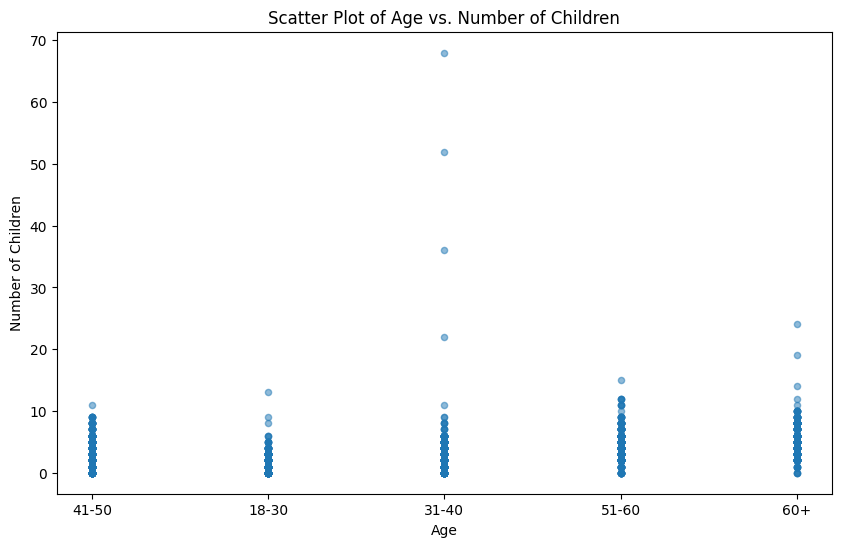

In [113]:
figure = healthcare_df.plot(
    kind="scatter", x="Age", y="Children", figsize=(10, 6), alpha=0.5
)

figure.set_title("Scatter Plot of Age vs. Number of Children")
figure.set_xlabel("Age")
figure.set_ylabel("Number of Children")
plt.show()


In [122]:
healthcare_df.loc[healthcare_df['Children'] >= 30]
# # healthcare_df[healthcare_df['Children'] >= 30]
# healthcare_df

,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Age,Gender,Marital Status,Children,Employment Status,Monthly Household Income,Health_Insurance,Insurance_cover,Last_Hosptal_visit,Last_Hosptal_visit_insurance,Check-up,Years_to_Checkup,Cancer_Screening,Years_to_Screening
6030,0.413850,34.152542,1212.1,4.7,31-40,Male,Married,52.0,Self-employed,20001-30000,Yes,NHIF,23.0,No,No,NaN,Yes,2
6034,0.416480,34.152103,1198.6,4.4,31-40,Female,Married,36.0,Employed,40001-50000,Yes,NHIF,0.0,No,Yes,1,Yes,1
6047,-0.894182,36.814429,0.0,3200.0,31-40,Female,Married,68.0,Unemployed,20001-30000,No,NaN,3.0,Yes,No,NaN,No,2


In [131]:
# healthcare_df.drop([6030, 6034,6047], inplace=True)
healthcare_df.loc[healthcare_df['Children'] >= 30]
healthcare_df.head(10)

,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Age,Gender,Marital Status,Children,Employment Status,Monthly Household Income,Health_Insurance,Insurance_cover,Last_Hosptal_visit,Last_Hosptal_visit_insurance,Check-up,Years_to_Checkup,Cancer_Screening,Years_to_Screening
0,-0.274201,36.058336,1882.200073,20.000,41-50,Female,Married,2.0,Self-employed,20001-30000,Yes,Nhif,53.0,No,Yes,2,No,2
1,-0.715812,37.147506,1361.900024,20.000,18-30,Male,Single,0.0,Unemployed,Less than 10000,No,NaN,8.0,No,Yes,1,No,NaN
2,-0.715816,37.147508,1361.900024,20.000,41-50,Female,Married,5.0,Self-employed,20001-30000,No,Nhif,6.0,Yes,No,NaN,Yes,4+
3,-0.715708,37.147490,1361.900024,20.000,18-30,Male,Single,0.0,Self-employed,10001-20000,Yes,Nhif,16.0,Yes,No,NaN,No,NaN
4,-0.715734,37.147480,1361.900024,20.000,41-50,Male,Married,7.0,Self-employed,20001-30000,Yes,Nhif,13.0,Yes,No,NaN,Yes,4+
5,-0.715804,37.147536,1361.900024,26.107,18-30,Female,Single,0.0,Unemployed,10001-20000,Yes,Nhif,2.0,Yes,No,NaN,No,NaN
6,-0.715893,37.147353,1361.599976,32.483,31-40,Female,Married,2.0,Self-employed,10001-20000,Yes,Nhif,4.0,Yes,No,NaN,No,NaN
7,-0.715940,37.146309,1362.200073,56.100,18-30,Male,Single,0.0,Self-employed,Less than 10000,No,NaN,24.0,No,No,NaN,No,NaN
8,-0.715912,37.147077,1362.200073,33.011,31-40,Female,Married,3.0,Employed,20001-30000,Yes,Nhif,5.0,Yes,No,NaN,No,NaN
9,-0.715871,37.146672,1362.200073,52.400,31-40,Female,Married,2.0,Employed,10001-20000,Yes,Nhif,6.0,Yes,No,NaN,No,NaN


In [139]:
healthcare_df.loc[(healthcare_df['Age'] == '31-40') & (healthcare_df['Children'] >= 20)]
#healthcare_df.drop(5565, inplace=True)

,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Age,Gender,Marital Status,Children,Employment Status,Monthly Household Income,Health_Insurance,Insurance_cover,Last_Hosptal_visit,Last_Hosptal_visit_insurance,Check-up,Years_to_Checkup,Cancer_Screening,Years_to_Screening


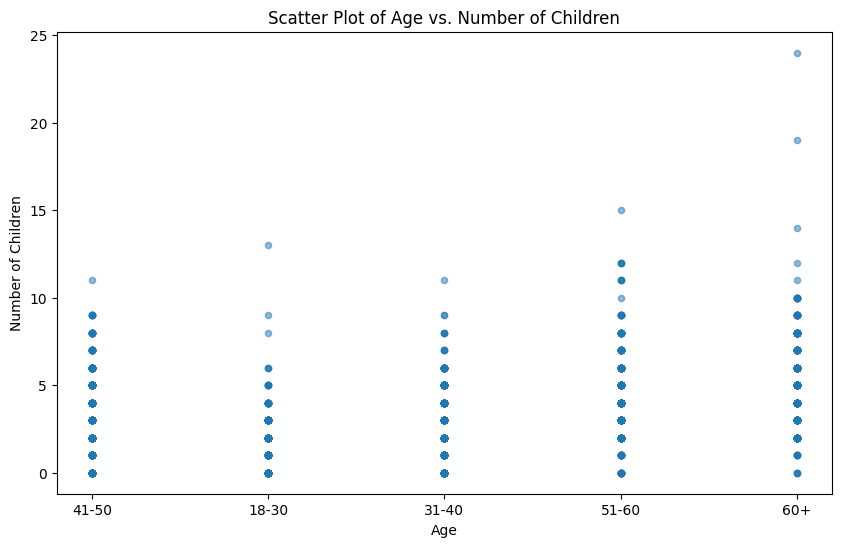

In [140]:
figure = healthcare_df.plot(
    kind="scatter", x="Age", y="Children", figsize=(10, 6), alpha=0.5
)

figure.set_title("Scatter Plot of Age vs. Number of Children")
figure.set_xlabel("Age")
figure.set_ylabel("Number of Children")
plt.show()

In [141]:
healthcare_df['Children'].max()

24.0

In [162]:
healthcare_df['Insurance_cover'] = healthcare_df['Insurance_cover'].str.upper()
healthcare_df['Insurance_cover'] == 'NHIF'

0        True
1       False
2        True
3        True
4        True
        ...  
6153    False
6154    False
6155     True
6156    False
6157     True
Name: Insurance_cover, Length: 5371, dtype: bool

In [163]:
healthcare_df.head()

,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Age,Gender,Marital Status,Children,Employment Status,Monthly Household Income,Health_Insurance,Insurance_cover,Last_Hosptal_visit,Last_Hosptal_visit_insurance,Check-up,Years_to_Checkup,Cancer_Screening,Years_to_Screening
0,-0.274201,36.058336,1882.200073,20.0,41-50,Female,Married,2.0,Self-employed,20001-30000,Yes,NHIF,53.0,No,Yes,2,No,2
1,-0.715812,37.147506,1361.900024,20.0,18-30,Male,Single,0.0,Unemployed,Less than 10000,No,NaN,8.0,No,Yes,1,No,NaN
2,-0.715816,37.147508,1361.900024,20.0,41-50,Female,Married,5.0,Self-employed,20001-30000,No,NHIF,6.0,Yes,No,NaN,Yes,4+
3,-0.715708,37.147490,1361.900024,20.0,18-30,Male,Single,0.0,Self-employed,10001-20000,Yes,NHIF,16.0,Yes,No,NaN,No,NaN
4,-0.715734,37.147480,1361.900024,20.0,41-50,Male,Married,7.0,Self-employed,20001-30000,Yes,NHIF,13.0,Yes,No,NaN,Yes,4+


In [187]:
healthcare_df['Insurance_cover'].value_counts()

Insurance_cover
NHIF                                            1444
NHIF                                             973
MAKUENI CARE                                      78
BRITAM                                            40
JUBILEE                                           39
                                                ... 
LIASON GROUP                                       1
NOT APPLICABLE CAUSE I DON'T HAVE INSURANCE        1
NHIF\nJUBILEE INSURANCE                            1
BRITAM COVER                                       1
CIC INSURANCE GROUP                                1
Name: count, Length: 202, dtype: int64

In [186]:
healthcare_df.loc[healthcare_df['Insurance_cover'] == '800165']
#healthcare_df.drop(2305, inplace=True)

,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Age,Gender,Marital Status,Children,Employment Status,Monthly Household Income,Health_Insurance,Insurance_cover,Last_Hosptal_visit,Last_Hosptal_visit_insurance,Check-up,Years_to_Checkup,Cancer_Screening,Years_to_Screening


In [196]:
# healthcare_df['Last_Hosptal_visit'].value_counts()
# healthcare_df.loc[healthcare_df['Last_Hosptal_visit'] == 2020.00]
# healthcare_df.loc[healthcare_df['Last_Hosptal_visit'] >= 80.00]
healthcare_df.drop(1458, inplace=True)


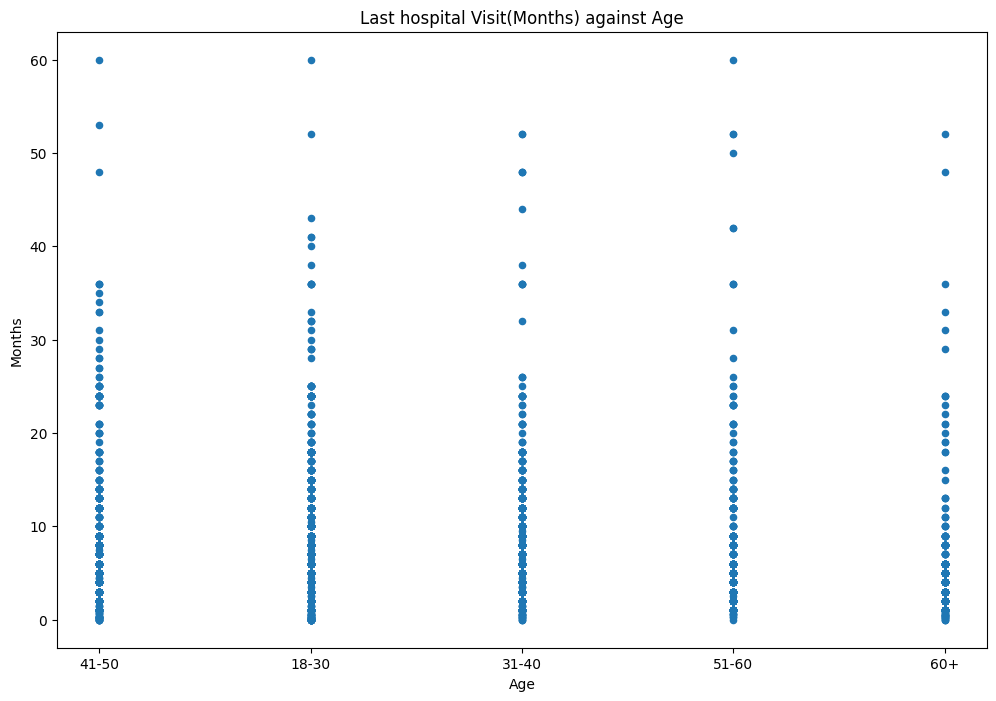

In [197]:
fig = healthcare_df.plot(kind='scatter', x="Age", y="Last_Hosptal_visit", figsize=(12,8))
fig.set_title('Last hospital Visit(Months) against Age')
fig.set_xlabel('Age')
fig.set_ylabel('Months')
plt.show()

In [202]:
healthcare_df['Last_Hosptal_visit'].max()
healthcare_df.head()

,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Age,Gender,Marital Status,Children,Employment Status,Monthly Household Income,Health_Insurance,Insurance_cover,Last_Hosptal_visit,Last_Hosptal_visit_insurance,Check-up,Years_to_Checkup,Cancer_Screening,Years_to_Screening
0,-0.274201,36.058336,1882.200073,20.0,41-50,Female,Married,2.0,Self-employed,20001-30000,Yes,NHIF,53.0,No,Yes,2,No,2
1,-0.715812,37.147506,1361.900024,20.0,18-30,Male,Single,0.0,Unemployed,Less than 10000,No,NaN,8.0,No,Yes,1,No,NaN
2,-0.715816,37.147508,1361.900024,20.0,41-50,Female,Married,5.0,Self-employed,20001-30000,No,NHIF,6.0,Yes,No,NaN,Yes,4+
3,-0.715708,37.147490,1361.900024,20.0,18-30,Male,Single,0.0,Self-employed,10001-20000,Yes,NHIF,16.0,Yes,No,NaN,No,NaN
4,-0.715734,37.147480,1361.900024,20.0,41-50,Male,Married,7.0,Self-employed,20001-30000,Yes,NHIF,13.0,Yes,No,NaN,Yes,4+


In [211]:
healthcare_df = healthcare_df[~((healthcare_df['Check-up'] == 'No') & (healthcare_df['Years_to_Checkup'].notna()))]

In [219]:
healthcare_df = healthcare_df[~((healthcare_df['Cancer_Screening'] == 'No') & (healthcare_df['Years_to_Screening'].notna()))]

In [230]:
healthcare_df.loc[(healthcare_df['Health_Insurance'] == 'No') & (healthcare_df['Insurance_cover'].notna()), 'Insurance_cover'] = healthcare_df['Insurance_cover'].replace(r'[\s\S]+', np.nan, regex=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_45528\157543215.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  healthcare_df.loc[(healthcare_df['Health_Insurance'] == 'No') & (healthcare_df['Insurance_cover'].notna()), 'Insurance_cover'] = healthcare_df['Insurance_cover'].replace(r'[\s\S]+', np.nan, regex=True)


In [231]:
healthcare_df.head(10)

,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Age,Gender,Marital Status,Children,Employment Status,Monthly Household Income,Health_Insurance,Insurance_cover,Last_Hosptal_visit,Last_Hosptal_visit_insurance,Check-up,Years_to_Checkup,Cancer_Screening,Years_to_Screening
1,-0.715812,37.147506,1361.900024,20.000,18-30,Male,Single,0.0,Unemployed,Less than 10000,No,NaN,8.0,No,Yes,1,No,NaN
2,-0.715816,37.147508,1361.900024,20.000,41-50,Female,Married,5.0,Self-employed,20001-30000,No,NaN,6.0,Yes,No,NaN,Yes,4+
3,-0.715708,37.147490,1361.900024,20.000,18-30,Male,Single,0.0,Self-employed,10001-20000,Yes,NHIF,16.0,Yes,No,NaN,No,NaN
4,-0.715734,37.147480,1361.900024,20.000,41-50,Male,Married,7.0,Self-employed,20001-30000,Yes,NHIF,13.0,Yes,No,NaN,Yes,4+
5,-0.715804,37.147536,1361.900024,26.107,18-30,Female,Single,0.0,Unemployed,10001-20000,Yes,NHIF,2.0,Yes,No,NaN,No,NaN
6,-0.715893,37.147353,1361.599976,32.483,31-40,Female,Married,2.0,Self-employed,10001-20000,Yes,NHIF,4.0,Yes,No,NaN,No,NaN
7,-0.715940,37.146309,1362.200073,56.100,18-30,Male,Single,0.0,Self-employed,Less than 10000,No,NaN,24.0,No,No,NaN,No,NaN
8,-0.715912,37.147077,1362.200073,33.011,31-40,Female,Married,3.0,Employed,20001-30000,Yes,NHIF,5.0,Yes,No,NaN,No,NaN
9,-0.715871,37.146672,1362.200073,52.400,31-40,Female,Married,2.0,Employed,10001-20000,Yes,NHIF,6.0,Yes,No,NaN,No,NaN
10,-0.716643,37.145942,1365.800049,98.400,18-30,Male,Single,0.0,Unemployed,Less than 10000,No,NaN,17.0,No,No,NaN,No,NaN


In [217]:
healthcare_df.tail(10)

,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,Age,Gender,Marital Status,Children,Employment Status,Monthly Household Income,Health_Insurance,Insurance_cover,Last_Hosptal_visit,Last_Hosptal_visit_insurance,Check-up,Years_to_Checkup,Cancer_Screening,Years_to_Screening
6148,-0.988309,36.858818,1807.100000,3.300,51-60,Male,Married,4.0,Self-employed,20001-30000,No,NaN,52.0,No,No,NaN,No,NaN
6149,-0.997367,36.871807,1807.100000,4.900,51-60,Female,Married,3.0,Self-employed,10001-20000,No,NaN,36.0,No,Yes,4+,No,NaN
6150,-0.997789,36.872784,1756.200000,4.925,41-50,Female,Married,4.0,Unemployed,Less than 10000,No,NaN,23.0,No,Yes,4+,No,NaN
6151,-0.987481,36.854175,1756.200000,4.900,60+,Female,Married,4.0,Self-employed,50001+,Yes,NHIF,13.0,Yes,Yes,4+,No,NaN
6152,-1.268939,36.892414,1617.800000,4.950,31-40,Male,Married,2.0,Self-employed,20001-30000,Yes,NHIF,6.0,Yes,Yes,3,No,NaN
6153,-1.269310,36.891695,1618.000000,4.816,18-30,Female,Single,0.0,Self-employed,Less than 10000,Yes,ICEA LION GROUP,3.0,Yes,Yes,2,No,NaN
6154,-1.270522,36.892388,1594.900024,5.000,41-50,Male,Married,6.0,Self-employed,40001-50000,Yes,APA INSURANCE,3.0,Yes,Yes,1,Yes,1
6155,-1.271808,36.893101,1594.900024,4.840,31-40,Female,Married,3.0,Employed,10001-20000,Yes,NHIF,6.0,Yes,No,NaN,Yes,2
6156,-1.273072,36.893833,1594.900024,4.840,31-40,Male,Divorced,2.0,Self-employed,Less than 10000,Yes,CIC INSURANCE GROUP,5.0,Yes,Yes,2,Yes,1
6157,-1.273937,36.894248,1594.900024,4.616,31-40,Female,Married,1.0,Unemployed,Less than 10000,Yes,NHIF,3.0,Yes,Yes,1,Yes,1


In [234]:
healthcare_df.to_excel('../data/interim/healthcare_cleaned.xlsx', index=False)